# 04_backtest_grid.py 결과 확인

`data/backtest_results`에 저장된 백테스트 결과를 확인한다.
- 전략별 최종 성과(누적수익률/MDD/샤프비율) 상위·하위 랭킹
- monthly vs quarterly 리밸런싱 주기별 비교
- 특정 전략 하나의 구간별 수익률 시계열 확인
- 종목 보유 수(held_count) 추이로 스크리닝이 정상 작동했는지 확인

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("spark://spark-master:7077").appName("check_backtest").getOrCreate()

summary = spark.read.parquet("/opt/spark-apps/data/backtest_results/summary")
period = spark.read.parquet("/opt/spark-apps/data/backtest_results/period_returns")

print(f"전략 수(summary): {summary.count()}")
print(f"구간 수익률 행 수(period_returns): {period.count()}")
summary.printSchema()

전략 수(summary): 1000
구간 수익률 행 수(period_returns): 20000
root
 |-- name: string (nullable = true)
 |-- final_cum_return: double (nullable = true)
 |-- mdd: double (nullable = true)
 |-- avg_period_return: double (nullable = true)
 |-- stddev_period_return: double (nullable = true)
 |-- sharpe_ratio: double (nullable = true)



## 1. 누적수익률 상위 20개 전략

In [2]:
top20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.desc("final_cum_return")).limit(20).toPandas()
top20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per20_pbr0.8_dynone_monthly_n20,-0.075823,-0.538033,0.008064,0.172123,0.046848
1,per15_pbr0.8_dynone_monthly_n20,-0.105652,-0.552944,0.006815,0.171234,0.039802
2,per12_pbr0.8_dynone_monthly_n20,-0.105652,-0.552944,0.006815,0.171234,0.039802
3,per10_pbr0.8_dynone_monthly_n20,-0.108251,-0.554243,0.006711,0.171223,0.039197
4,per20_pbr1.0_dynone_monthly_n20,-0.109446,-0.554840,0.006792,0.171938,0.039504
5,per12_pbr2.0_dynone_monthly_n20,-0.116583,-0.558408,0.006359,0.171017,0.037182
6,per12_pbr1.2_dynone_monthly_n20,-0.116583,-0.558408,0.006359,0.171017,0.037182
7,per12_pbr1.5_dynone_monthly_n20,-0.116583,-0.558408,0.006359,0.171017,0.037182
8,per15_pbr1.2_dynone_monthly_n20,-0.116583,-0.558408,0.006359,0.171017,0.037182
9,per15_pbr1.5_dynone_monthly_n20,-0.116583,-0.558408,0.006359,0.171017,0.037182


## 2. 누적수익률 하위 20개 전략

In [3]:
bottom20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.asc("final_cum_return")).limit(20).toPandas()
bottom20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per20_pbr1.5_dynone_quarterly_n10,-0.692252,-0.601537,-0.104583,0.117615,-0.889199
1,per20_pbr1.2_dynone_quarterly_n10,-0.692252,-0.601537,-0.104583,0.117615,-0.889199
2,per20_pbr2.0_dynone_quarterly_n10,-0.692252,-0.601537,-0.104583,0.117615,-0.889199
3,per8_pbr1.0_dynone_quarterly_n10,-0.684002,-0.614255,-0.103428,0.105373,-0.981540
4,per20_pbr1.0_dynone_quarterly_n10,-0.679553,-0.608825,-0.102011,0.107079,-0.952676
5,per12_pbr1.0_dynone_quarterly_n10,-0.677008,-0.605718,-0.101257,0.107510,-0.941833
6,per15_pbr1.0_dynone_quarterly_n10,-0.677008,-0.605718,-0.101257,0.107510,-0.941833
7,per10_pbr1.0_dynone_quarterly_n10,-0.674604,-0.602784,-0.100580,0.107570,-0.935018
8,per20_pbr1.5_dynone_monthly_n10,-0.672276,-0.684183,-0.033299,0.080344,-0.414457
9,per20_pbr1.2_dynone_monthly_n10,-0.672276,-0.684183,-0.033299,0.080344,-0.414457


## 3. 샤프비율 상위 20개 전략 (수익률 대비 위험조정 성과)

In [4]:
top_sharpe = summary.filter(F.col("sharpe_ratio").isNotNull()) \
    .orderBy(F.desc("sharpe_ratio")).limit(20).toPandas()
top_sharpe

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per20_pbr0.8_dynone_quarterly_n20,-0.148044,-0.472802,0.018490,0.322672,0.057302
1,per10_pbr0.8_dynone_quarterly_n20,-0.167823,-0.472802,0.015530,0.320614,0.048439
2,per20_pbr0.8_dynone_monthly_n20,-0.075823,-0.538033,0.008064,0.172123,0.046848
3,per15_pbr0.8_dynone_quarterly_n20,-0.182439,-0.472802,0.013897,0.321176,0.043269
4,per12_pbr0.8_dynone_quarterly_n20,-0.182439,-0.472802,0.013897,0.321176,0.043269
5,per20_pbr1.0_dynone_quarterly_n20,-0.186913,-0.472802,0.013359,0.321232,0.041586
6,per20_pbr2.0_dynone_quarterly_n20,-0.202686,-0.461526,0.013354,0.327237,0.040807
7,per20_pbr1.2_dynone_quarterly_n20,-0.202686,-0.461526,0.013354,0.327237,0.040807
8,per20_pbr1.5_dynone_quarterly_n20,-0.202686,-0.461526,0.013354,0.327237,0.040807
9,per15_pbr0.8_dynone_monthly_n20,-0.105652,-0.552944,0.006815,0.171234,0.039802


## 4. monthly vs quarterly 리밸런싱 주기 비교
전략 이름에서 rebalance 종류를 뽑아 그룹별 평균 성과를 비교한다.
(이름 규칙: `per{PER상한}_pbr{PBR상한}_dy{배당하한}_{rebalance}_n{보유종목수}`)

In [5]:
with_rebalance = summary.withColumn(
    "rebalance",
    F.when(F.col("name").contains("_monthly_"), "monthly").otherwise("quarterly"),
)

with_rebalance.groupBy("rebalance").agg(
    F.avg("final_cum_return").alias("avg_final_cum_return"),
    F.avg("mdd").alias("avg_mdd"),
    F.avg("sharpe_ratio").alias("avg_sharpe_ratio"),
    F.count("*").alias("strategy_count"),
).toPandas()

,rebalance,avg_final_cum_return,avg_mdd,avg_sharpe_ratio,strategy_count
0,quarterly,-0.497349,-0.440004,-0.648165,500
1,monthly,-0.472288,-0.564582,-0.259616,500


## 5. 특정 전략 하나의 구간별 수익률 시계열
이름을 바꿔서 원하는 전략의 리밸런싱 구간별 수익률 흐름을 확인할 수 있다.

In [6]:
target_strategy = "per8_pbr1.2_dynone_monthly_n10"

one_strategy = period.filter(F.col("name") == target_strategy) \
    .orderBy("period_start").toPandas()
one_strategy

,name,period_return,held_count,period_start,period_end
0,per8_pbr1.2_dynone_monthly_n10,0.035482,2,20210630,20210731
1,per8_pbr1.2_dynone_monthly_n10,-0.161244,2,20210731,20210831
2,per8_pbr1.2_dynone_monthly_n10,-0.049980,2,20210831,20210930
3,per8_pbr1.2_dynone_monthly_n10,-0.008708,4,20210930,20211031
4,per8_pbr1.2_dynone_monthly_n10,-0.065319,6,20211031,20211130
5,per8_pbr1.2_dynone_monthly_n10,0.068204,7,20211130,20211231
6,per8_pbr1.2_dynone_monthly_n10,0.005553,8,20211231,20220131
7,per8_pbr1.2_dynone_monthly_n10,-0.054956,8,20220131,20220228
8,per8_pbr1.2_dynone_monthly_n10,0.054543,10,20220228,20220331
9,per8_pbr1.2_dynone_monthly_n10,-0.024401,10,20220331,20220430


### 누적수익률 곡선 그래프

/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_25495/504836011.py:10: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/IPyth

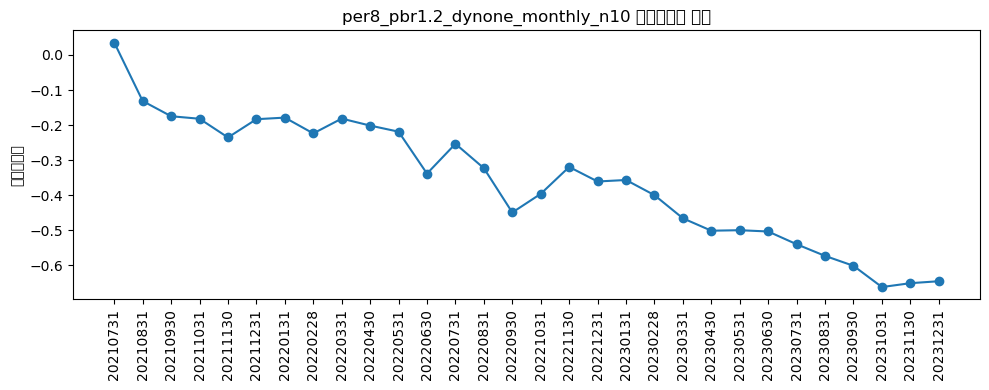

In [7]:
import matplotlib.pyplot as plt

one_strategy["cum_return"] = (1 + one_strategy["period_return"]).cumprod() - 1

plt.figure(figsize=(10, 4))
plt.plot(one_strategy["period_end"], one_strategy["cum_return"], marker="o")
plt.xticks(rotation=90)
plt.title(f"{target_strategy} 누적수익률 추이")
plt.ylabel("누적수익률")
plt.tight_layout()
plt.show()

## 6. 종목 보유 수(held_count) 추이
시점이 갈수록 그 시점 이전에 공시된 사업보고서가 누적되므로, 초반 시점(2021년 초)은 held_count가
적고 뒤로 갈수록 늘어나는 것이 정상이다 (룩어헤드 바이어스 방지 로직이 실제로 작동하는 증거).

In [8]:
held_trend = period.filter(F.col("name") == target_strategy) \
    .select("period_start", "held_count").orderBy("period_start").toPandas()
held_trend

,period_start,held_count
0,20210630,2
1,20210731,2
2,20210831,2
3,20210930,4
4,20211031,6
5,20211130,7
6,20211231,8
7,20220131,8
8,20220228,10
9,20220331,10


## 7. 이상치 확인: final_cum_return이 null인 전략
구간 수익률 계산 자체가 안 된 전략(예: 어느 시점에도 조건을 만족하는 종목이 없었던 전략)이 있는지 확인.

In [9]:
null_result = summary.filter(F.col("final_cum_return").isNull())
print(f"결과 없는 전략 수: {null_result.count()}")
null_result.toPandas()

결과 없는 전략 수: 0


,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio


In [10]:
spark.stop()